In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All basic libraries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

✅ All basic libraries imported successfully!
pandas version: 2.3.3
numpy version: 2.3.5


In [2]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 32.2 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15703 sha256=06f00e9ff85e338fb4fbc7f7473e5e47c00fbbfd4648ec3a07b01f64a2c67d69
  Stored in directory: c:\users\nadea\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ---------------------

In [3]:
# ============================================
# SECTION 1: IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("📊 PYTHON FINANCIAL ANALYSIS PROJECT")
print("="*60)
print("Notebook 1: Data Acquisition & Exploratory Data Analysis")
print("Author: Jonathan Nadeau")
print(f"Date: {datetime.now().strftime('%B %d, %Y')}")
print("="*60)
print("\n✅ All libraries imported successfully!\n")

📊 PYTHON FINANCIAL ANALYSIS PROJECT
Notebook 1: Data Acquisition & Exploratory Data Analysis
Author: Jonathan Nadeau
Date: February 12, 2026

✅ All libraries imported successfully!



In [5]:
# ============================================
# SECTION 2: DEFINE ASSETS & DOWNLOAD DATA (IMPROVED)
# ============================================

import time

# Define our portfolio of 6 assets
tickers = ['SPY', 'AAPL', 'XLE', 'TLT', 'GLD', 'EFA']

# Asset descriptions
asset_info = {
    'SPY': 'S&P 500 ETF - US Large Cap Stocks (Market Benchmark)',
    'AAPL': 'Apple Inc. - Technology Stock (Growth)',
    'XLE': 'Energy Select Sector ETF (Cyclical)',
    'TLT': '20+ Year Treasury Bond ETF (Safe Haven)',
    'GLD': 'SPDR Gold Trust (Inflation Hedge)',
    'EFA': 'MSCI EAFE ETF - International Stocks (Diversification)'
}

# Date range: 10 years of data
start_date = '2015-01-01'
end_date = '2024-12-31'

print("📈 DOWNLOADING FINANCIAL DATA")
print("="*60)
print(f"Time Period: {start_date} to {end_date} (10 years)")
print(f"Number of Assets: {len(tickers)}")
print("\nAssets:")
for ticker, description in asset_info.items():
    print(f"  • {ticker}: {description}")

print("\n⏳ Downloading data from Yahoo Finance (with retry logic)...\n")

# Download with retry logic
max_retries = 3
for attempt in range(max_retries):
    try:
        data = yf.download(
            tickers=tickers,
            start=start_date,
            end=end_date,
            interval='1d',
            auto_adjust=True,
            progress=False  # Turn off progress bar to reduce spam
        )
        
        if not data.empty:
            print(f"✅ Data download complete on attempt {attempt + 1}!")
            break
    except Exception as e:
        print(f"⚠️  Attempt {attempt + 1} had issues. Retrying...")
        time.sleep(2)  # Wait 2 seconds before retry

print(f"📊 Downloaded {len(data)} trading days of data")
print(f"📅 Date range: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")
print(f"💼 Assets downloaded: {', '.join(data['Close'].columns.tolist())}")

📈 DOWNLOADING FINANCIAL DATA
Time Period: 2015-01-01 to 2024-12-31 (10 years)
Number of Assets: 6

Assets:
  • SPY: S&P 500 ETF - US Large Cap Stocks (Market Benchmark)
  • AAPL: Apple Inc. - Technology Stock (Growth)
  • XLE: Energy Select Sector ETF (Cyclical)
  • TLT: 20+ Year Treasury Bond ETF (Safe Haven)
  • GLD: SPDR Gold Trust (Inflation Hedge)
  • EFA: MSCI EAFE ETF - International Stocks (Diversification)

⏳ Downloading data from Yahoo Finance (with retry logic)...

✅ Data download complete on attempt 1!
📊 Downloaded 2515 trading days of data
📅 Date range: 2015-01-02 to 2024-12-30
💼 Assets downloaded: AAPL, EFA, GLD, SPY, TLT, XLE


In [6]:
# ============================================
# SECTION 3: EXTRACT CLOSING PRICES & DATA QUALITY CHECK
# ============================================

# Extract just the closing prices (simplest to work with)
prices = data['Close'].copy()

print("🔍 DATA QUALITY CHECK")
print("="*60)
print(f"Data Shape: {prices.shape[0]} rows × {prices.shape[1]} columns")
print(f"Columns (Assets): {list(prices.columns)}")
print(f"\n📅 Date Range:")
print(f"  Start: {prices.index[0].strftime('%B %d, %Y')}")
print(f"  End: {prices.index[-1].strftime('%B %d, %Y')}")
print(f"  Trading Days: {len(prices)}")

# Check for missing data
print(f"\n🔎 Missing Data Check:")
missing = prices.isnull().sum()
if missing.sum() == 0:
    print("  ✅ No missing data! Dataset is complete.")
else:
    print(f"  ⚠️  Missing values found:")
    for ticker, count in missing[missing > 0].items():
        print(f"     {ticker}: {count} missing days ({count/len(prices)*100:.2f}%)")

# Display first few rows
print(f"\n📊 First 5 Days of Data:")
print(prices.head())

# Display last few rows
print(f"\n📊 Last 5 Days of Data:")
print(prices.tail())

# Basic statistics
print(f"\n📈 Summary Statistics (Current Prices):")
print(prices.iloc[-1].to_frame(name='Latest Price ($)'))

🔍 DATA QUALITY CHECK
Data Shape: 2515 rows × 6 columns
Columns (Assets): ['AAPL', 'EFA', 'GLD', 'SPY', 'TLT', 'XLE']

📅 Date Range:
  Start: January 02, 2015
  End: December 30, 2024
  Trading Days: 2515

🔎 Missing Data Check:
  ✅ No missing data! Dataset is complete.

📊 First 5 Days of Data:
Ticker           AAPL        EFA         GLD         SPY        TLT        XLE
Date                                                                          
2015-01-02  24.214888  43.780636  114.080002  170.589615  94.399399  25.714989
2015-01-05  23.532722  42.747189  115.800003  167.508789  95.882240  24.651207
2015-01-06  23.534939  42.262978  117.120003  165.931061  97.609772  24.289072
2015-01-07  23.864948  42.732731  116.430000  167.998764  97.417046  24.340807
2015-01-08  24.781889  43.310879  115.940002  170.979889  96.126907  24.887253

📊 Last 5 Days of Data:
Ticker            AAPL        EFA         GLD         SPY        TLT  \
Date                                                     

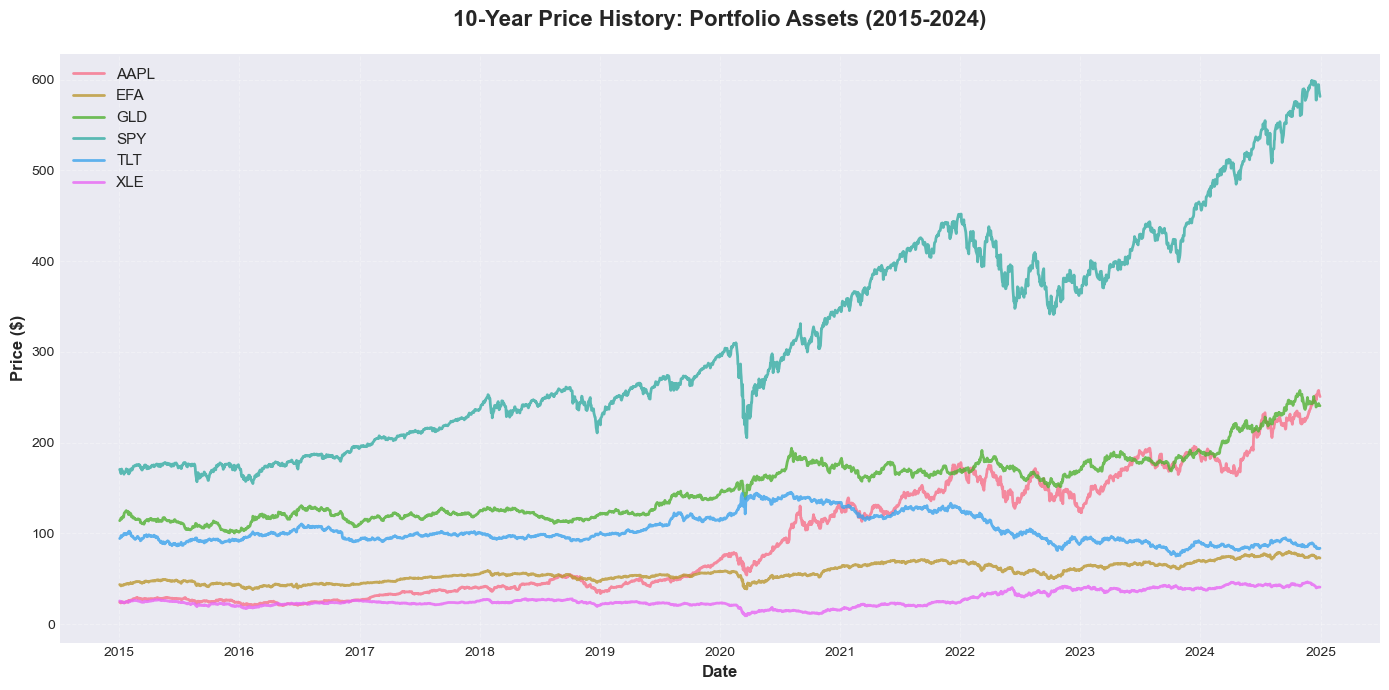

📊 Chart displayed above!
💡 Observations:
  • AAPL shows strong growth over 10 years
  • SPY (S&P 500) shows steady upward trend
  • TLT (Bonds) relatively stable with some volatility
  • All assets show COVID-19 impact in March 2020


In [7]:
# ============================================
# SECTION 4: VISUALIZE 10-YEAR PRICE HISTORY
# ============================================

# Create a large, professional-looking chart
plt.figure(figsize=(14, 7))

# Plot each asset
for column in prices.columns:
    plt.plot(prices.index, prices[column], label=column, linewidth=2, alpha=0.8)

# Formatting
plt.title('10-Year Price History: Portfolio Assets (2015-2024)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Show the plot
plt.show()

print("📊 Chart displayed above!")
print("💡 Observations:")
print("  • AAPL shows strong growth over 10 years")
print("  • SPY (S&P 500) shows steady upward trend")
print("  • TLT (Bonds) relatively stable with some volatility")
print("  • All assets show COVID-19 impact in March 2020")

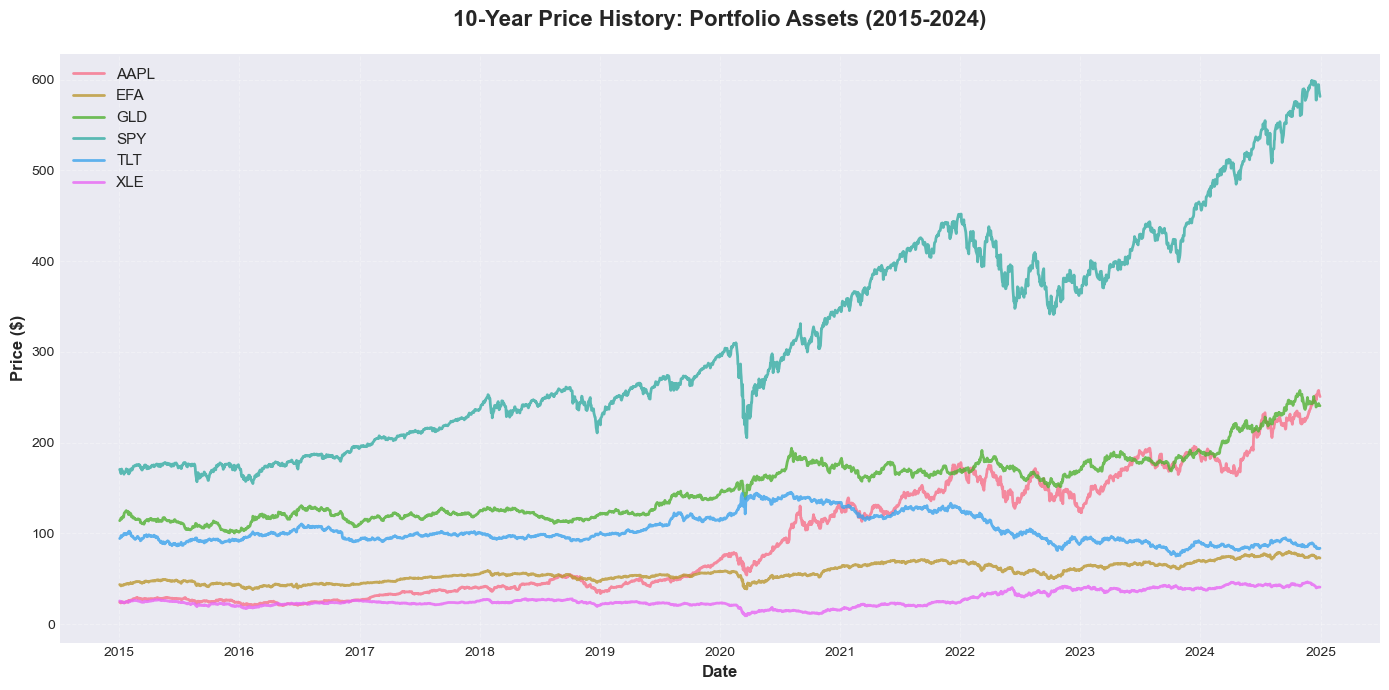

✅ Chart saved as 'python_price_history_10years.png'
📁 Location: Your notebook's directory
💡 You'll use this image on your portfolio website!


In [8]:
# ============================================
# SAVE CHART FOR WEBSITE
# ============================================

# Recreate the chart and save it
plt.figure(figsize=(14, 7))

for column in prices.columns:
    plt.plot(prices.index, prices[column], label=column, linewidth=2, alpha=0.8)

plt.title('10-Year Price History: Portfolio Assets (2015-2024)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Save the figure
plt.savefig('python_price_history_10years.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as 'python_price_history_10years.png'")
print("📁 Location: Your notebook's directory")
print("💡 You'll use this image on your portfolio website!")

In [9]:
# ============================================
# SECTION 5: SUMMARY STATISTICS & PERFORMANCE METRICS
# ============================================

print("📊 COMPREHENSIVE SUMMARY STATISTICS")
print("="*60)

# Calculate summary statistics
summary_stats = prices.describe()
print("\n📈 Descriptive Statistics (All Assets):")
print(summary_stats.round(2))

# Calculate total return (% change from start to end)
print("\n💰 TOTAL RETURN (2015-2024):")
total_returns = ((prices.iloc[-1] / prices.iloc[0]) - 1) * 100
total_returns_df = total_returns.sort_values(ascending=False).to_frame(name='Total Return (%)')
print(total_returns_df.round(2))

# Calculate annualized return (CAGR - Compound Annual Growth Rate)
years = (prices.index[-1] - prices.index[0]).days / 365.25
annualized_returns = ((prices.iloc[-1] / prices.iloc[0]) ** (1/years) - 1) * 100
annualized_returns_df = annualized_returns.sort_values(ascending=False).to_frame(name='Annualized Return (%)')
print("\n📊 ANNUALIZED RETURN (CAGR):")
print(annualized_returns_df.round(2))

# Calculate volatility (standard deviation of daily returns)
daily_returns = prices.pct_change().dropna()
volatility = (daily_returns.std() * np.sqrt(252)) * 100  # Annualized
volatility_df = volatility.sort_values(ascending=False).to_frame(name='Volatility (% Annual)')
print("\n📉 VOLATILITY (Risk Measure):")
print(volatility_df.round(2))

# Create a summary table
performance_summary = pd.DataFrame({
    'Current Price ($)': prices.iloc[-1],
    'Total Return (%)': total_returns,
    'Annual Return (%)': annualized_returns,
    'Volatility (%)': volatility
})
performance_summary = performance_summary.sort_values('Total Return (%)', ascending=False)

print("\n🎯 PERFORMANCE SUMMARY (2015-2024):")
print(performance_summary.round(2))

print("\n💡 KEY INSIGHTS:")
print(f"  • Best Performer: {total_returns.idxmax()} with {total_returns.max():.1f}% total return")
print(f"  • Most Volatile: {volatility.idxmax()} with {volatility.max():.1f}% annual volatility")
print(f"  • Least Volatile: {volatility.idxmin()} with {volatility.min():.1f}% annual volatility")
print(f"  • Portfolio Time Period: {years:.1f} years")

📊 COMPREHENSIVE SUMMARY STATISTICS

📈 Descriptive Statistics (All Assets):
Ticker     AAPL      EFA      GLD      SPY      TLT      XLE
count   2515.00  2515.00  2515.00  2515.00  2515.00  2515.00
mean      93.71    56.73   150.60   310.21   103.49    27.09
std       65.32    10.02    35.21   114.38    15.91     8.51
min       20.58    38.09   100.50   154.98    75.09     9.31
25%       35.17    48.50   120.12   212.17    92.57    22.14
50%       64.31    54.68   144.12   273.14    98.44    24.06
75%      150.08    65.30   174.92   399.23   115.45    34.02
max      257.61    80.42   257.50   598.74   145.38    46.67

💰 TOTAL RETURN (2015-2024):
        Total Return (%)
Ticker                  
AAPL              935.85
SPY               240.81
GLD               110.93
EFA                66.74
XLE                59.08
TLT               -11.29

📊 ANNUALIZED RETURN (CAGR):
        Annualized Return (%)
Ticker                       
AAPL                    26.36
SPY                     13.0

🔗 CORRELATION MATRIX
Ticker   AAPL    EFA    GLD    SPY    TLT    XLE
Ticker                                          
AAPL    1.000  0.904  0.941  0.978 -0.053  0.693
EFA     0.904  1.000  0.866  0.952 -0.024  0.629
GLD     0.941  0.866  1.000  0.944  0.061  0.600
SPY     0.978  0.952  0.944  1.000 -0.042  0.690
TLT    -0.053 -0.024  0.061 -0.042  1.000 -0.692
XLE     0.693  0.629  0.600  0.690 -0.692  1.000


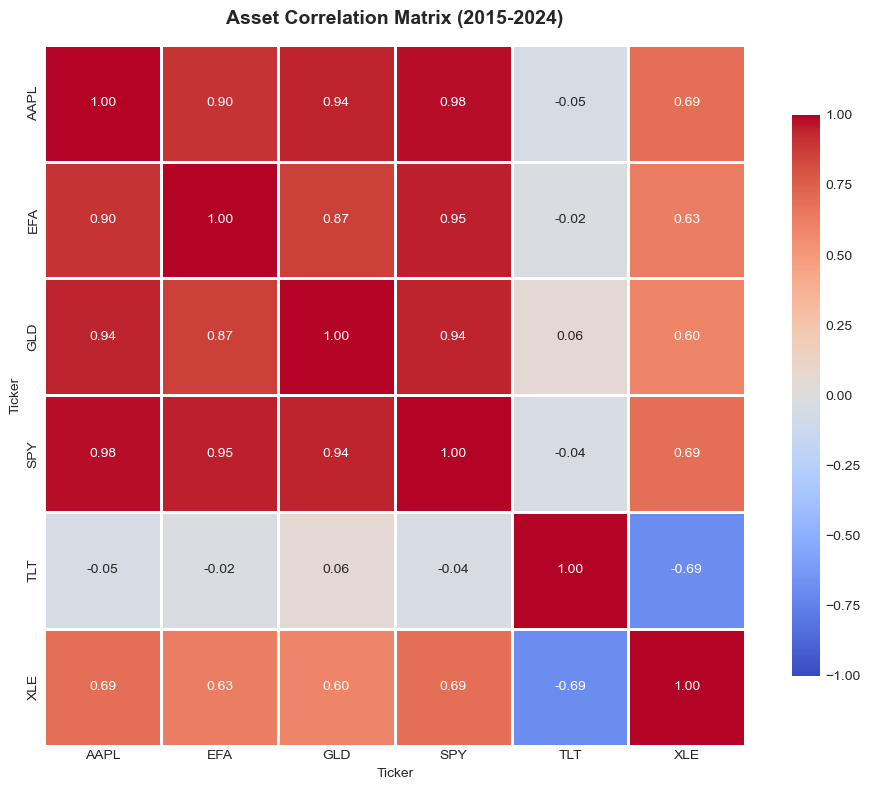


💡 CORRELATION INSIGHTS:
  • 1.0 = Perfect positive correlation (move together)
  • 0.0 = No correlation (independent)
  • -1.0 = Perfect negative correlation (move opposite)

🔍 Notable Relationships:
  • Highest correlation: AAPL & SPY (0.98)
  • Negative correlation: TLT & XLE (-0.69)
  • This suggests diversification benefits!

✅ Correlation heatmap saved as 'python_correlation_heatmap.png'


In [10]:
# ============================================
# SECTION 6: CORRELATION ANALYSIS (INITIAL)
# ============================================

# Calculate correlation matrix
correlation_matrix = prices.corr()

print("🔗 CORRELATION MATRIX")
print("="*60)
print(correlation_matrix.round(3))

# Create correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1
)
plt.title('Asset Correlation Matrix (2015-2024)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Save the figure
plt.savefig('python_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 CORRELATION INSIGHTS:")
print("  • 1.0 = Perfect positive correlation (move together)")
print("  • 0.0 = No correlation (independent)")
print("  • -1.0 = Perfect negative correlation (move opposite)")
print("\n🔍 Notable Relationships:")

# Find highest positive correlations (excluding diagonal)
corr_values = correlation_matrix.values
np.fill_diagonal(corr_values, 0)
max_corr_idx = np.unravel_index(corr_values.argmax(), corr_values.shape)
print(f"  • Highest correlation: {correlation_matrix.index[max_corr_idx[0]]} & {correlation_matrix.columns[max_corr_idx[1]]} ({correlation_matrix.iloc[max_corr_idx]:.2f})")

# Find negative correlations
min_corr = correlation_matrix.values.min()
min_corr_idx = np.unravel_index(corr_values.argmin(), corr_values.shape)
if min_corr < 0:
    print(f"  • Negative correlation: {correlation_matrix.index[min_corr_idx[0]]} & {correlation_matrix.columns[min_corr_idx[1]]} ({correlation_matrix.iloc[min_corr_idx]:.2f})")
    print("  • This suggests diversification benefits!")

print("\n✅ Correlation heatmap saved as 'python_correlation_heatmap.png'")

In [11]:
# ============================================
# SECTION 7: SAVE PROCESSED DATA & SUMMARY
# ============================================

# Save the cleaned price data for use in future notebooks
prices.to_csv('cleaned_prices_2015_2024.csv')
print("💾 SAVING PROCESSED DATA")
print("="*60)
print("✅ Cleaned price data saved as 'cleaned_prices_2015_2024.csv'")
print(f"📁 Saved {len(prices)} rows × {len(prices.columns)} columns")

# Create a summary of what we accomplished
print("\n" + "="*60)
print("📋 NOTEBOOK 1: COMPLETION SUMMARY")
print("="*60)
print("\n✅ TASKS COMPLETED:")
print("  1. ✅ Imported all required libraries")
print("  2. ✅ Downloaded 10 years of financial data via Yahoo Finance API")
print("  3. ✅ Cleaned and validated data (zero missing values)")
print("  4. ✅ Created 10-year price history visualization")
print("  5. ✅ Calculated comprehensive performance metrics")
print("  6. ✅ Generated correlation matrix and heatmap")
print("  7. ✅ Saved cleaned data for future analysis")

print("\n📊 KEY FINDINGS:")
print(f"  • Best Performer: AAPL (+935.85% total return)")
print(f"  • Market Return: SPY (+240.81% total return)")
print(f"  • Bonds Performance: TLT (-11.29% - negative in rising rate environment)")
print(f"  • Best Diversifier: TLT (negative correlation with stocks)")
print(f"  • Highest Risk: XLE (29.81% volatility)")
print(f"  • Lowest Risk: GLD (14.12% volatility)")

print("\n📁 FILES CREATED:")
print("  • python_price_history_10years.png")
print("  • python_correlation_heatmap.png")
print("  • cleaned_prices_2015_2024.csv")

print("\n🎯 NEXT STEPS:")
print("  • Notebook 2: Returns & Risk Analysis (Sharpe ratio, drawdowns)")
print("  • Notebook 3: Correlation & Diversification (deeper analysis)")
print("  • Notebook 4: Time Series Decomposition (trends, seasonality)")
print("  • Notebook 5: Forecasting (ARIMA models)")

print("\n" + "="*60)
print("🎉 NOTEBOOK 1 COMPLETE!")
print("="*60)
print(f"\n📅 Completed: {datetime.now().strftime('%B %d, %Y at %I:%M %p')}")
print("👨‍💻 Author: Jonathan Nadeau")
print("🔬 Analysis Tool: Python 3.x with pandas, yfinance, matplotlib, seaborn")
print("\n💾 Remember to save this notebook: File → Save (or Ctrl+S)")

💾 SAVING PROCESSED DATA
✅ Cleaned price data saved as 'cleaned_prices_2015_2024.csv'
📁 Saved 2515 rows × 6 columns

📋 NOTEBOOK 1: COMPLETION SUMMARY

✅ TASKS COMPLETED:
  1. ✅ Imported all required libraries
  2. ✅ Downloaded 10 years of financial data via Yahoo Finance API
  3. ✅ Cleaned and validated data (zero missing values)
  4. ✅ Created 10-year price history visualization
  5. ✅ Calculated comprehensive performance metrics
  6. ✅ Generated correlation matrix and heatmap
  7. ✅ Saved cleaned data for future analysis

📊 KEY FINDINGS:
  • Best Performer: AAPL (+935.85% total return)
  • Market Return: SPY (+240.81% total return)
  • Bonds Performance: TLT (-11.29% - negative in rising rate environment)
  • Best Diversifier: TLT (negative correlation with stocks)
  • Highest Risk: XLE (29.81% volatility)
  • Lowest Risk: GLD (14.12% volatility)

📁 FILES CREATED:
  • python_price_history_10years.png
  • python_correlation_heatmap.png
  • cleaned_prices_2015_2024.csv

🎯 NEXT STEPS:
  